<h3> Informações Iniciais para Realização da Atividade 3</h3>
 
<ul>
<li><b>Predict Students' Dropout and Academic Success</li>
<li><b>URL:</b> 
<a href="https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success" target="_blank">
https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success
</a>
</li>
<li><b>Número de Colunas (Atributos):</b> 36</li>
<li><b>Número de Objetos (Instâncias):</b> 4424</li>
<li><b>Número de Rótulos:</b> 1</li>
<li><b>Possui dados faltantes:</b> Não</li>
<li><b>Possui dados categóricos:</b> Sim</li>
</ul>

<p style="text-align: justify;">
    O código completo apresentado a seguir corresponde a uma etapa do processo de visualização de dados aplicado à mineração de um dataset previamente selecionado. Seu objetivo é analisar, por meio de histogramas e outros gráficos estatísticos, as informações disponíveis no conjunto de dados, buscando identificar possíveis relações entre as diferentes classes, bem como padrões relevantes que possam auxiliar em uma etapa posterior de redução de dimensionalidade dos dados.
</p>

In [8]:

# Importação da biblioteca pandas para manipulação de DataFrames e numpy e math para operações matemáticas
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [9]:

# Leitura do arquivo .csv por meio da biblioteca pandas
original_students_df = pd.read_csv("predict_students_dropout_and_academic_success.csv", sep = ";")


<p style="text-align: justify;">
    Inicialmente, realizou-se um levantamento de 18 variáveis numéricas, sejam elas discretas ou contínuas, com o objetivo de selecionar aquelas mais adequadas para a construção de histogramas e para a definição de intervalos de classe. Embora a base de dados original contenha um total de 36 atributos, nem todos são apropriados para esse tipo de visualização, uma vez que apresentam diferentes naturezas e escalas. Em especial, variáveis categóricas codificadas numericamente não são, em geral, bem representadas por histogramas, já que esse tipo de gráfico é mais indicado para a análise da distribuição de frequências de variáveis quantitativas. Dessa forma, foram selecionadas as colunas que melhor se adequam a essa proposta, apresentadas a seguir juntamente com a tradução de seus nomes do inglês para o português. Para isso, criou-se o dataframe <i>processed_students_df</i>, contendo apenas os atributos escolhidos. Por fim, utilizou-se o método <i>.head()</i> para visualizar as primeiras linhas desse novo conjunto de dados.
</p>

In [10]:

# Atribuição das colunas numéricas a uma variável para um novo Dataframe para manipulação
# Tradução de cada coluna ao lado para melhor entendimento do que é cada coisa

colunas_histograma = [
    'Previous qualification (grade)',                       # Qualificação anterior (nota)
    'Admission grade',                                      # Nota de admissão
    'Age at enrollment',                                    # Idade de matrícula
    'Curricular units 1st sem (credited)',                  # Unidades curriculares 1o semestre (creditadas aproveitamento)
    'Curricular units 1st sem (enrolled)',                  # Unidades curriculares 1o semestre (matriculadas)
    'Curricular units 1st sem (evaluations)',               # Unidades curriculares 1o semestre (avaliações aplicadas)
    'Curricular units 1st sem (approved)',                  # Unidades curriculares 1o semestre (aprovadas)
    'Curricular units 1st sem (grade)',                     # Unidades curriculares 1o semestre (nota)
    'Curricular units 1st sem (without evaluations)',       # Unidades curriculares 1o semestre (sem avaliações)
    'Curricular units 2nd sem (credited)',                  # Unidades curriculares 2o semestre (creditadas aproveitamento)
    'Curricular units 2nd sem (enrolled)',                  # Unidades curriculares 2o semestre (matriculadas)
    'Curricular units 2nd sem (evaluations)',               # Unidades curriculares 2o semestre (avaliações aplicadas)
    'Curricular units 2nd sem (approved)',                  # Unidades curriculares 2o semestre (aprovadas)
    'Curricular units 2nd sem (grade)',                     # Unidades curriculares 2o semestre (nota)
    'Curricular units 2nd sem (without evaluations)',       # Unidades curriculares 2o semestre (sem avaliações)
    'Unemployment rate',                                    # Indice desemprego
    'Inflation rate',                                       # Indice de inflação
    'GDP'                                                   # PIB 
]


In [11]:

# atribuição das colunas numéricas elencadas antes em um novo Dataframe e impressão para verificação de êxito
processed_students_df = original_students_df[colunas_histograma]
processed_students_df.head()


,Previous qualification (grade),Admission grade,Age at enrollment,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
0,122.0,127.3,20,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74
1,160.0,142.5,19,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79
2,122.0,124.8,19,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74
3,122.0,119.6,20,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12
4,100.0,141.5,45,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79


<p style="text-align: justify;">
    Considerando a necessidade de gerar histogramas para 18 colunas distintas, a abordagem mais adequada e eficiente foi a utilização de funções específicas para cada etapa do processo, evitando a repetição excessiva de código. Dessa forma, foram desenvolvidas três funções, apresentadas a seguir: uma destinada à plotagem e exibição dos histogramas com o auxílio da biblioteca matplotlib. Assim, uma outra função voltada à impressão de informações complementares logo após a exibição dos gráficos, permitindo identificar a quantidade de valores em cada classe de cada histograma. E, por fim, uma função responsável pelo cálculo das distribuições de frequência, incluindo os valores mínimos e máximos de cada intervalo de classe, bem como a definição do número de classes utilizado.
</p>

In [51]:

# Definição de função para plotar histogramas com as colunas do novo Dataframe
def plotar_grafico_histograma(column, contagens, bins):
    larguras = [bins[i + 1] - bins[i] for i in range(len(bins) - 1)]
    plt.figure(figsize = (8, 5))
    plt.bar(
        bins[:-1],               # início de cada classe
        contagens,               # frequência de cada classe
        width = larguras,        # largura de cada barra
        align = 'edge',          # barra começa no limite inferior
        edgecolor = 'black',
        color = 'purple',
        zorder = 3
        )
    plt.title(f'Histograma - {column}')
    plt.xlabel(column)
    plt.ylabel('Frequência')
    plt.grid(axis = 'y', linestyle = '--', alpha = 0.2, color = 'black')
    plt.xticks(bins, rotation = 45)
    plt.tight_layout()
    plt.show()

# Definição de função para impressão das informações de cada histograma plotado
def imprimir_informacoes(contagens, bins, column, k, h, amplitude_total):
    print(f'\nDistribuição de frequências - {column}')
    print('-' * 60)
    print(f'Número de classes (k): {k}')
    print(f'Amplitude total: {amplitude_total:.4f}')
    print(f'Largura de classe (h): {h:.4f}')
    print('-' * 60)
    
    for i in range(len(contagens)):
        li = bins[i]
        ls = bins[i + 1]
        freq = contagens[i]
        print(f'Classe {i+1:02d}: [{li:.2f}, {ls:.2f}] --> {freq}')

# Definição de função para cálculo de cada classe de histograma
def distribuicoes_frequencias():
    for column in processed_students_df.columns:
        n = len(processed_students_df[column])
        k = math.ceil(1 + 3.322 * math.log10(n))
        valor_min = np.min(processed_students_df[column])
        valor_max = np.max(processed_students_df[column])
        amplitude_total = valor_max - valor_min
        h = amplitude_total / k
        
        bins = [valor_min + i * h for i in range(k + 1)]
        bins[-1] = valor_max
        contagens = [0] * k
        
        for valor in processed_students_df[column]:
            for i in range(k):
                li = bins[i]
                ls = bins[i + 1]
                if i == k - 1:
                    if li <= valor <= ls:
                        contagens[i] += 1
                        break
                else:
                    if li <= valor < ls:
                        contagens[i] += 1
                        break
    
        plotar_grafico_histograma(column, contagens, bins)
        imprimir_informacoes(contagens, bins, column, k, h, amplitude_total)


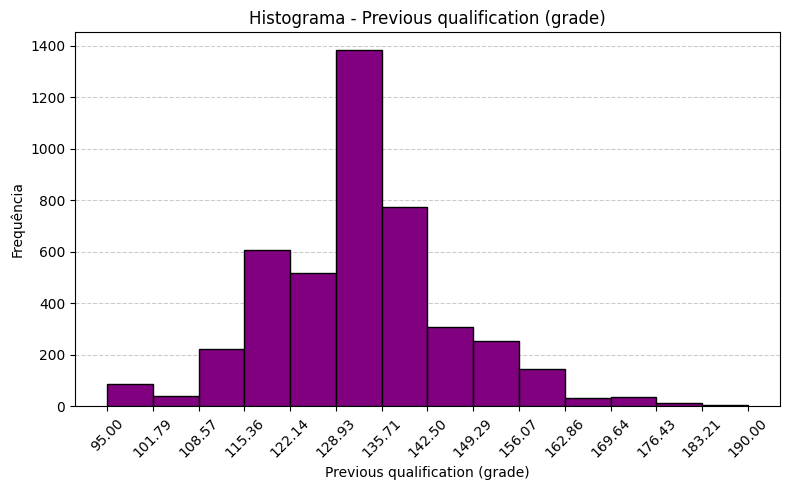


Distribuição de frequências - Previous qualification (grade)
------------------------------------------------------------
Número de classes (k): 14
Amplitude total: 95.0000
Largura de classe (h): 6.7857
------------------------------------------------------------
Classe 01: [95.00, 101.79] --> 88
Classe 02: [101.79, 108.57] --> 42
Classe 03: [108.57, 115.36] --> 224
Classe 04: [115.36, 122.14] --> 607
Classe 05: [122.14, 128.93] --> 517
Classe 06: [128.93, 135.71] --> 1382
Classe 07: [135.71, 142.50] --> 772
Classe 08: [142.50, 149.29] --> 308
Classe 09: [149.29, 156.07] --> 254
Classe 10: [156.07, 162.86] --> 144
Classe 11: [162.86, 169.64] --> 33
Classe 12: [169.64, 176.43] --> 35
Classe 13: [176.43, 183.21] --> 14
Classe 14: [183.21, 190.00] --> 4


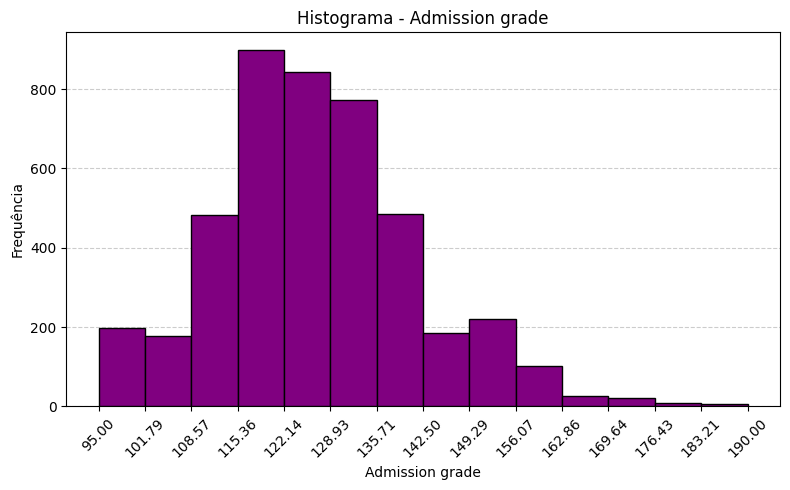


Distribuição de frequências - Admission grade
------------------------------------------------------------
Número de classes (k): 14
Amplitude total: 95.0000
Largura de classe (h): 6.7857
------------------------------------------------------------
Classe 01: [95.00, 101.79] --> 197
Classe 02: [101.79, 108.57] --> 177
Classe 03: [108.57, 115.36] --> 482
Classe 04: [115.36, 122.14] --> 898
Classe 05: [122.14, 128.93] --> 842
Classe 06: [128.93, 135.71] --> 772
Classe 07: [135.71, 142.50] --> 485
Classe 08: [142.50, 149.29] --> 186
Classe 09: [149.29, 156.07] --> 221
Classe 10: [156.07, 162.86] --> 101
Classe 11: [162.86, 169.64] --> 26
Classe 12: [169.64, 176.43] --> 22
Classe 13: [176.43, 183.21] --> 9
Classe 14: [183.21, 190.00] --> 6


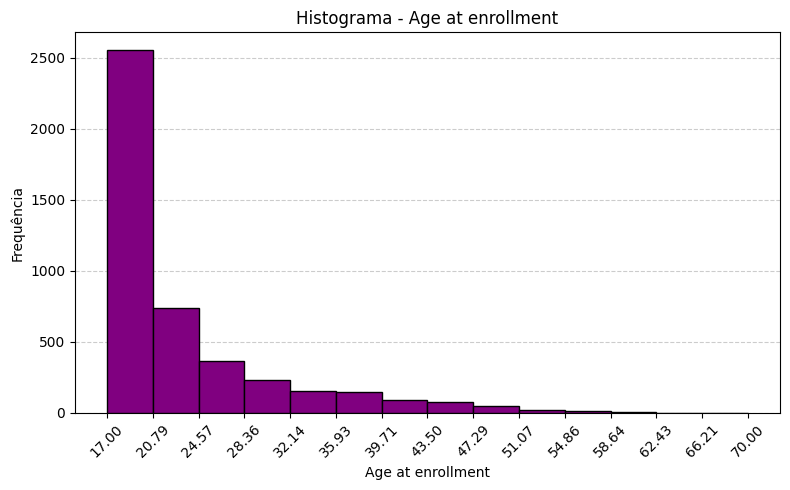


Distribuição de frequências - Age at enrollment
------------------------------------------------------------
Número de classes (k): 14
Amplitude total: 53.0000
Largura de classe (h): 3.7857
------------------------------------------------------------
Classe 01: [17.00, 20.79] --> 2551
Classe 02: [20.79, 24.57] --> 735
Classe 03: [24.57, 28.36] --> 361
Classe 04: [28.36, 32.14] --> 231
Classe 05: [32.14, 35.93] --> 154
Classe 06: [35.93, 39.71] --> 144
Classe 07: [39.71, 43.50] --> 92
Classe 08: [43.50, 47.29] --> 73
Classe 09: [47.29, 51.07] --> 47
Classe 10: [51.07, 54.86] --> 18
Classe 11: [54.86, 58.64] --> 10
Classe 12: [58.64, 62.43] --> 7
Classe 13: [62.43, 66.21] --> 0
Classe 14: [66.21, 70.00] --> 1


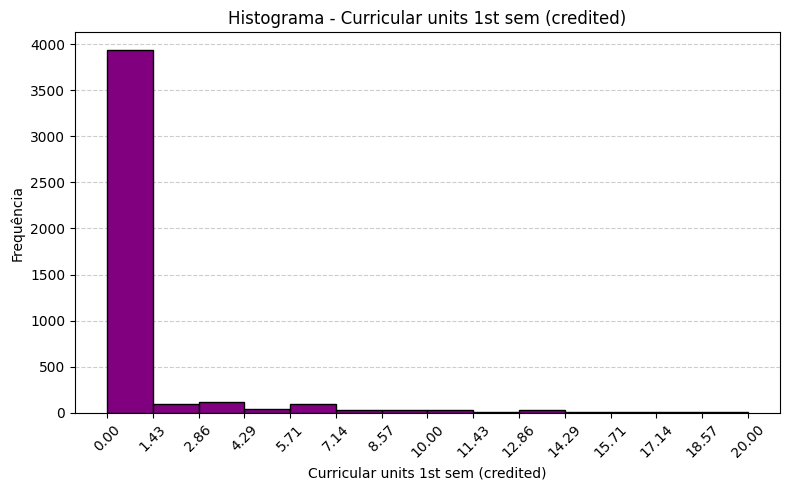


Distribuição de frequências - Curricular units 1st sem (credited)
------------------------------------------------------------
Número de classes (k): 14
Amplitude total: 20.0000
Largura de classe (h): 1.4286
------------------------------------------------------------
Classe 01: [0.00, 1.43] --> 3932
Classe 02: [1.43, 2.86] --> 94
Classe 03: [2.86, 4.29] --> 116
Classe 04: [4.29, 5.71] --> 41
Classe 05: [5.71, 7.14] --> 92
Classe 06: [7.14, 8.57] --> 31
Classe 07: [8.57, 10.00] --> 27
Classe 08: [10.00, 11.43] --> 32
Classe 09: [11.43, 12.86] --> 12
Classe 10: [12.86, 14.29] --> 28
Classe 11: [14.29, 15.71] --> 5
Classe 12: [15.71, 17.14] --> 6
Classe 13: [17.14, 18.57] --> 4
Classe 14: [18.57, 20.00] --> 4


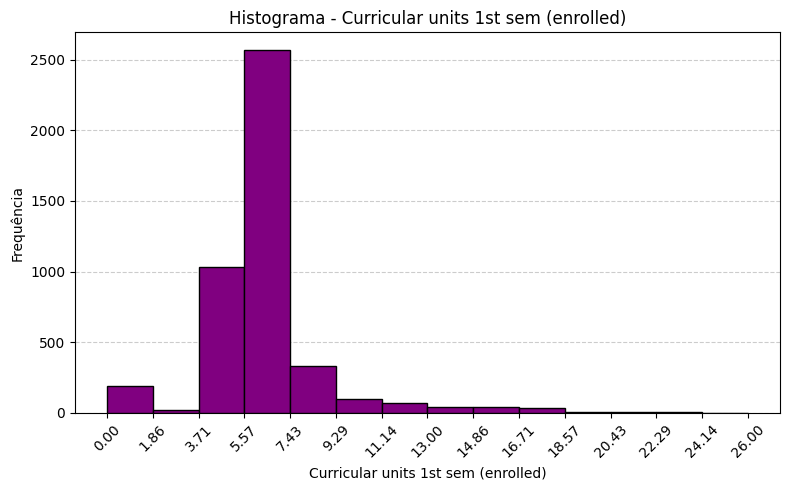


Distribuição de frequências - Curricular units 1st sem (enrolled)
------------------------------------------------------------
Número de classes (k): 14
Amplitude total: 26.0000
Largura de classe (h): 1.8571
------------------------------------------------------------
Classe 01: [0.00, 1.86] --> 187
Classe 02: [1.86, 3.71] --> 19
Classe 03: [3.71, 5.57] --> 1031
Classe 04: [5.57, 7.43] --> 2566
Classe 05: [7.43, 9.29] --> 332
Classe 06: [9.29, 11.14] --> 97
Classe 07: [11.14, 13.00] --> 66
Classe 08: [13.00, 14.86] --> 42
Classe 09: [14.86, 16.71] --> 38
Classe 10: [16.71, 18.57] --> 35
Classe 11: [18.57, 20.43] --> 2
Classe 12: [20.43, 22.29] --> 6
Classe 13: [22.29, 24.14] --> 2
Classe 14: [24.14, 26.00] --> 1


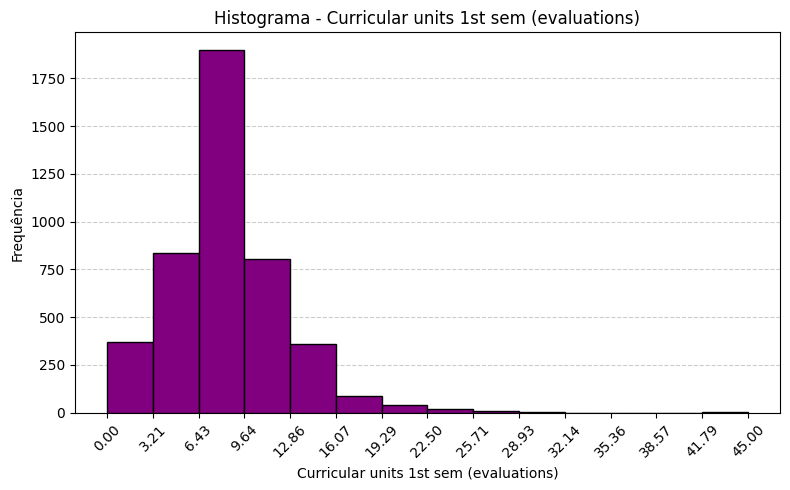


Distribuição de frequências - Curricular units 1st sem (evaluations)
------------------------------------------------------------
Número de classes (k): 14
Amplitude total: 45.0000
Largura de classe (h): 3.2143
------------------------------------------------------------
Classe 01: [0.00, 3.21] --> 369
Classe 02: [3.21, 6.43] --> 837
Classe 03: [6.43, 9.64] --> 1896
Classe 04: [9.64, 12.86] --> 802
Classe 05: [12.86, 16.07] --> 362
Classe 06: [16.07, 19.29] --> 86
Classe 07: [19.29, 22.50] --> 39
Classe 08: [22.50, 25.71] --> 18
Classe 09: [25.71, 28.93] --> 7
Classe 10: [28.93, 32.14] --> 4
Classe 11: [32.14, 35.36] --> 1
Classe 12: [35.36, 38.57] --> 1
Classe 13: [38.57, 41.79] --> 0
Classe 14: [41.79, 45.00] --> 2


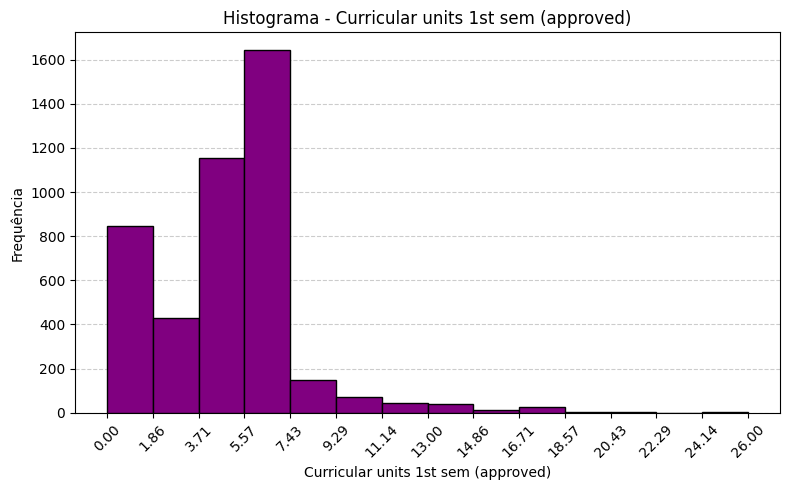


Distribuição de frequências - Curricular units 1st sem (approved)
------------------------------------------------------------
Número de classes (k): 14
Amplitude total: 26.0000
Largura de classe (h): 1.8571
------------------------------------------------------------
Classe 01: [0.00, 1.86] --> 845
Classe 02: [1.86, 3.71] --> 429
Classe 03: [3.71, 5.57] --> 1156
Classe 04: [5.57, 7.43] --> 1642
Classe 05: [7.43, 9.29] --> 148
Classe 06: [9.29, 11.14] --> 73
Classe 07: [11.14, 13.00] --> 44
Classe 08: [13.00, 14.86] --> 40
Classe 09: [14.86, 16.71] --> 12
Classe 10: [16.71, 18.57] --> 25
Classe 11: [18.57, 20.43] --> 5
Classe 12: [20.43, 22.29] --> 4
Classe 13: [22.29, 24.14] --> 0
Classe 14: [24.14, 26.00] --> 1


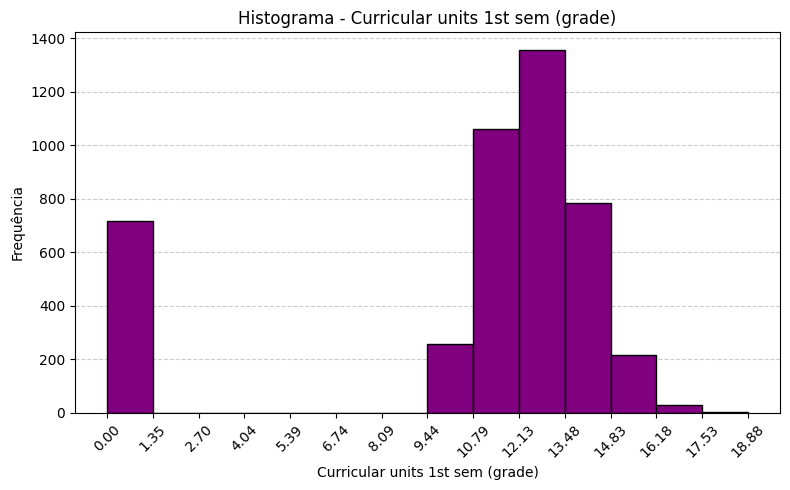


Distribuição de frequências - Curricular units 1st sem (grade)
------------------------------------------------------------
Número de classes (k): 14
Amplitude total: 18.8750
Largura de classe (h): 1.3482
------------------------------------------------------------
Classe 01: [0.00, 1.35] --> 718
Classe 02: [1.35, 2.70] --> 0
Classe 03: [2.70, 4.04] --> 0
Classe 04: [4.04, 5.39] --> 0
Classe 05: [5.39, 6.74] --> 0
Classe 06: [6.74, 8.09] --> 0
Classe 07: [8.09, 9.44] --> 0
Classe 08: [9.44, 10.79] --> 257
Classe 09: [10.79, 12.13] --> 1062
Classe 10: [12.13, 13.48] --> 1355
Classe 11: [13.48, 14.83] --> 784
Classe 12: [14.83, 16.18] --> 216
Classe 13: [16.18, 17.53] --> 29
Classe 14: [17.53, 18.88] --> 3


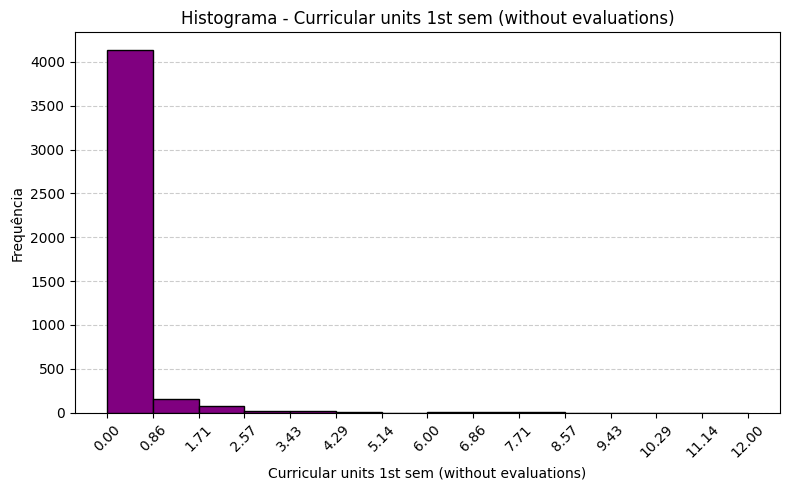


Distribuição de frequências - Curricular units 1st sem (without evaluations)
------------------------------------------------------------
Número de classes (k): 14
Amplitude total: 12.0000
Largura de classe (h): 0.8571
------------------------------------------------------------
Classe 01: [0.00, 0.86] --> 4130
Classe 02: [0.86, 1.71] --> 153
Classe 03: [1.71, 2.57] --> 79
Classe 04: [2.57, 3.43] --> 23
Classe 05: [3.43, 4.29] --> 15
Classe 06: [4.29, 5.14] --> 5
Classe 07: [5.14, 6.00] --> 0
Classe 08: [6.00, 6.86] --> 6
Classe 09: [6.86, 7.71] --> 6
Classe 10: [7.71, 8.57] --> 4
Classe 11: [8.57, 9.43] --> 0
Classe 12: [9.43, 10.29] --> 1
Classe 13: [10.29, 11.14] --> 0
Classe 14: [11.14, 12.00] --> 2


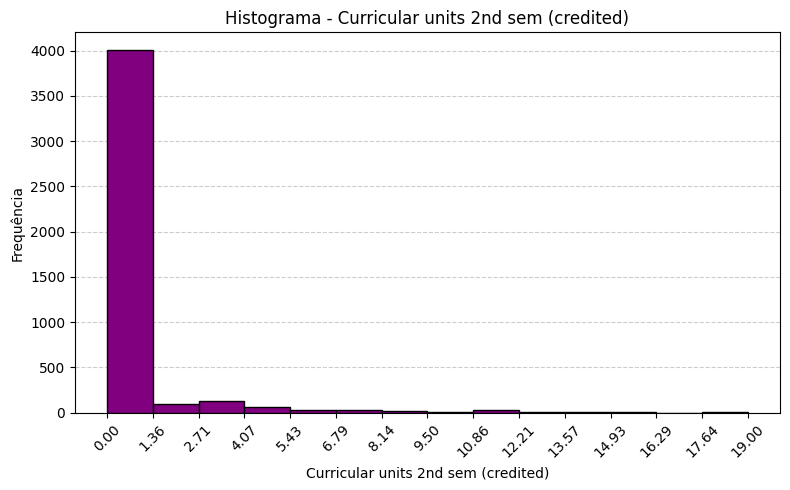


Distribuição de frequências - Curricular units 2nd sem (credited)
------------------------------------------------------------
Número de classes (k): 14
Amplitude total: 19.0000
Largura de classe (h): 1.3571
------------------------------------------------------------
Classe 01: [0.00, 1.36] --> 4001
Classe 02: [1.36, 2.71] --> 92
Classe 03: [2.71, 4.07] --> 127
Classe 04: [4.07, 5.43] --> 68
Classe 05: [5.43, 6.79] --> 26
Classe 06: [6.79, 8.14] --> 28
Classe 07: [8.14, 9.50] --> 15
Classe 08: [9.50, 10.86] --> 13
Classe 09: [10.86, 12.21] --> 34
Classe 10: [12.21, 13.57] --> 9
Classe 11: [13.57, 14.93] --> 4
Classe 12: [14.93, 16.29] --> 4
Classe 13: [16.29, 17.64] --> 0
Classe 14: [17.64, 19.00] --> 3


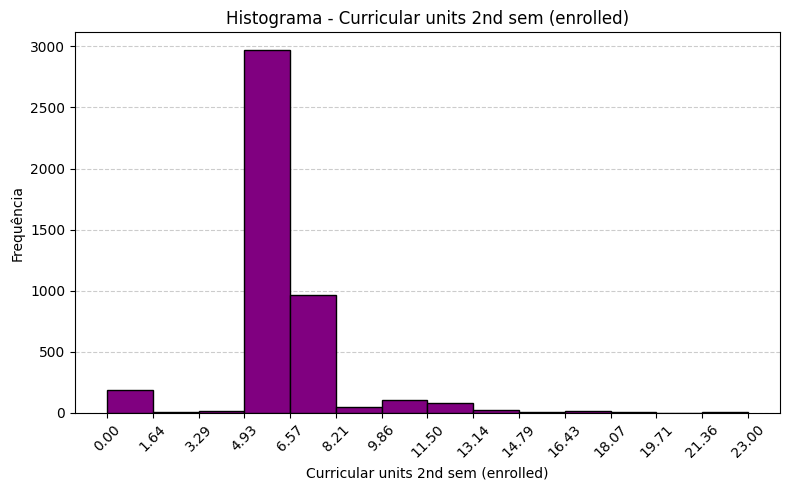


Distribuição de frequências - Curricular units 2nd sem (enrolled)
------------------------------------------------------------
Número de classes (k): 14
Amplitude total: 23.0000
Largura de classe (h): 1.6429
------------------------------------------------------------
Classe 01: [0.00, 1.64] --> 183
Classe 02: [1.64, 3.29] --> 8
Classe 03: [3.29, 4.93] --> 17
Classe 04: [4.93, 6.57] --> 2967
Classe 05: [6.57, 8.21] --> 965
Classe 06: [8.21, 9.86] --> 50
Classe 07: [9.86, 11.50] --> 108
Classe 08: [11.50, 13.14] --> 81
Classe 09: [13.14, 14.79] --> 22
Classe 10: [14.79, 16.43] --> 3
Classe 11: [16.43, 18.07] --> 14
Classe 12: [18.07, 19.71] --> 3
Classe 13: [19.71, 21.36] --> 1
Classe 14: [21.36, 23.00] --> 2


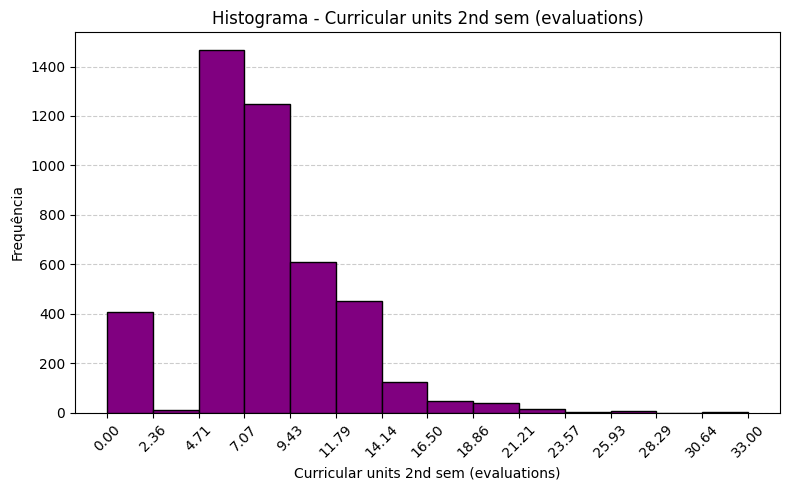


Distribuição de frequências - Curricular units 2nd sem (evaluations)
------------------------------------------------------------
Número de classes (k): 14
Amplitude total: 33.0000
Largura de classe (h): 2.3571
------------------------------------------------------------
Classe 01: [0.00, 2.36] --> 408
Classe 02: [2.36, 4.71] --> 12
Classe 03: [4.71, 7.07] --> 1465
Classe 04: [7.07, 9.43] --> 1248
Classe 05: [9.43, 11.79] --> 610
Classe 06: [11.79, 14.14] --> 450
Classe 07: [14.14, 16.50] --> 122
Classe 08: [16.50, 18.86] --> 47
Classe 09: [18.86, 21.21] --> 37
Classe 10: [21.21, 23.57] --> 14
Classe 11: [23.57, 25.93] --> 4
Classe 12: [25.93, 28.29] --> 6
Classe 13: [28.29, 30.64] --> 0
Classe 14: [30.64, 33.00] --> 1


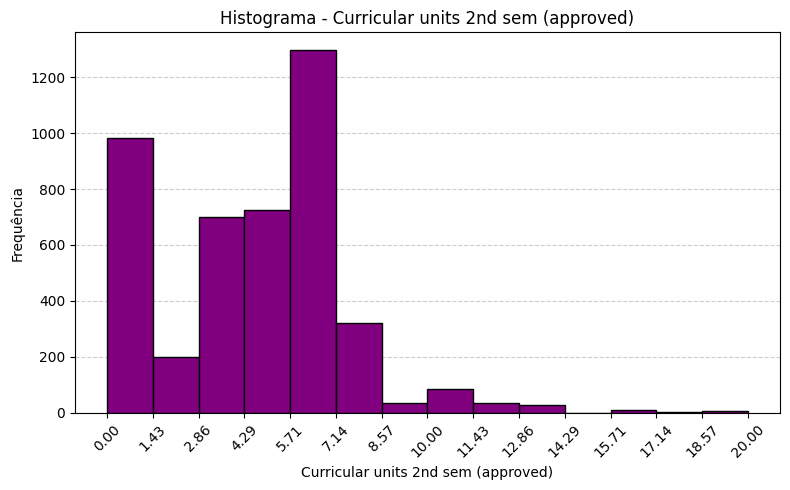


Distribuição de frequências - Curricular units 2nd sem (approved)
------------------------------------------------------------
Número de classes (k): 14
Amplitude total: 20.0000
Largura de classe (h): 1.4286
------------------------------------------------------------
Classe 01: [0.00, 1.43] --> 984
Classe 02: [1.43, 2.86] --> 198
Classe 03: [2.86, 4.29] --> 699
Classe 04: [4.29, 5.71] --> 726
Classe 05: [5.71, 7.14] --> 1296
Classe 06: [7.14, 8.57] --> 321
Classe 07: [8.57, 10.00] --> 36
Classe 08: [10.00, 11.43] --> 86
Classe 09: [11.43, 12.86] --> 34
Classe 10: [12.86, 14.29] --> 27
Classe 11: [14.29, 15.71] --> 0
Classe 12: [15.71, 17.14] --> 10
Classe 13: [17.14, 18.57] --> 2
Classe 14: [18.57, 20.00] --> 5


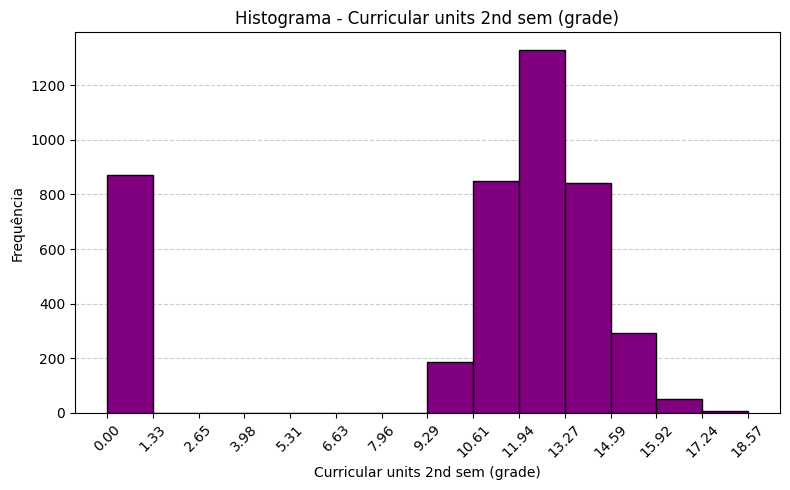


Distribuição de frequências - Curricular units 2nd sem (grade)
------------------------------------------------------------
Número de classes (k): 14
Amplitude total: 18.5714
Largura de classe (h): 1.3265
------------------------------------------------------------
Classe 01: [0.00, 1.33] --> 870
Classe 02: [1.33, 2.65] --> 0
Classe 03: [2.65, 3.98] --> 0
Classe 04: [3.98, 5.31] --> 0
Classe 05: [5.31, 6.63] --> 0
Classe 06: [6.63, 7.96] --> 0
Classe 07: [7.96, 9.29] --> 0
Classe 08: [9.29, 10.61] --> 185
Classe 09: [10.61, 11.94] --> 849
Classe 10: [11.94, 13.27] --> 1328
Classe 11: [13.27, 14.59] --> 842
Classe 12: [14.59, 15.92] --> 291
Classe 13: [15.92, 17.24] --> 52
Classe 14: [17.24, 18.57] --> 7


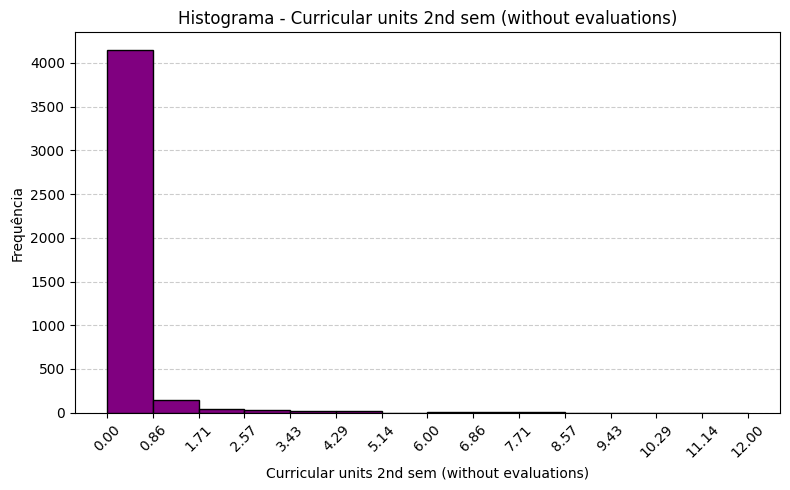


Distribuição de frequências - Curricular units 2nd sem (without evaluations)
------------------------------------------------------------
Número de classes (k): 14
Amplitude total: 12.0000
Largura de classe (h): 0.8571
------------------------------------------------------------
Classe 01: [0.00, 0.86] --> 4142
Classe 02: [0.86, 1.71] --> 140
Classe 03: [1.71, 2.57] --> 48
Classe 04: [2.57, 3.43] --> 35
Classe 05: [3.43, 4.29] --> 21
Classe 06: [4.29, 5.14] --> 17
Classe 07: [5.14, 6.00] --> 0
Classe 08: [6.00, 6.86] --> 8
Classe 09: [6.86, 7.71] --> 5
Classe 10: [7.71, 8.57] --> 6
Classe 11: [8.57, 9.43] --> 0
Classe 12: [9.43, 10.29] --> 0
Classe 13: [10.29, 11.14] --> 0
Classe 14: [11.14, 12.00] --> 2


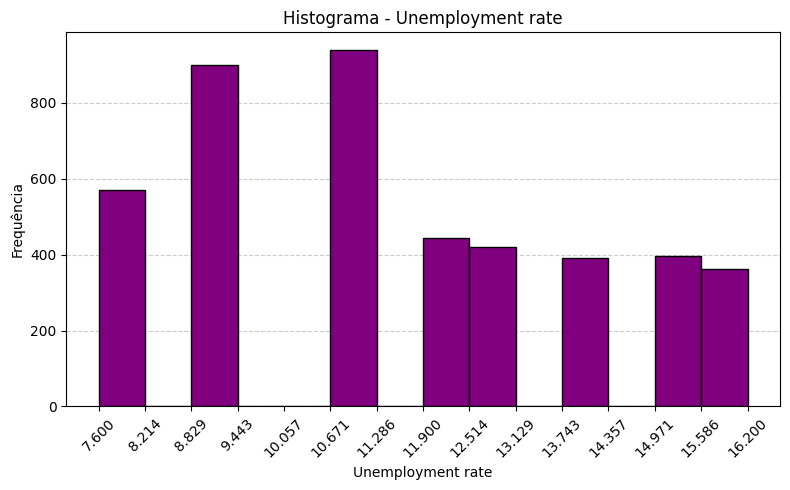


Distribuição de frequências - Unemployment rate
------------------------------------------------------------
Número de classes (k): 14
Amplitude total: 8.6000
Largura de classe (h): 0.6143
------------------------------------------------------------
Classe 01: [7.60, 8.21] --> 571
Classe 02: [8.21, 8.83] --> 0
Classe 03: [8.83, 9.44] --> 901
Classe 04: [9.44, 10.06] --> 0
Classe 05: [10.06, 10.67] --> 0
Classe 06: [10.67, 11.29] --> 939
Classe 07: [11.29, 11.90] --> 0
Classe 08: [11.90, 12.51] --> 445
Classe 09: [12.51, 13.13] --> 419
Classe 10: [13.13, 13.74] --> 0
Classe 11: [13.74, 14.36] --> 390
Classe 12: [14.36, 14.97] --> 0
Classe 13: [14.97, 15.59] --> 397
Classe 14: [15.59, 16.20] --> 362


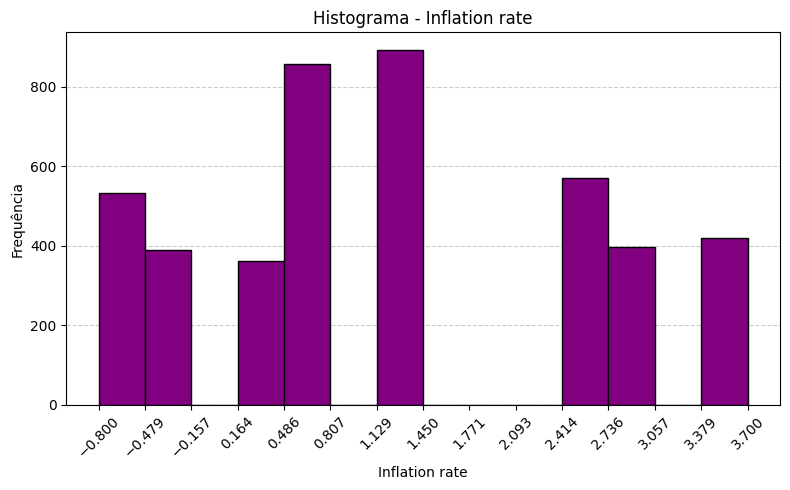


Distribuição de frequências - Inflation rate
------------------------------------------------------------
Número de classes (k): 14
Amplitude total: 4.5000
Largura de classe (h): 0.3214
------------------------------------------------------------
Classe 01: [-0.80, -0.48] --> 533
Classe 02: [-0.48, -0.16] --> 390
Classe 03: [-0.16, 0.16] --> 0
Classe 04: [0.16, 0.49] --> 362
Classe 05: [0.49, 0.81] --> 859
Classe 06: [0.81, 1.13] --> 0
Classe 07: [1.13, 1.45] --> 893
Classe 08: [1.45, 1.77] --> 0
Classe 09: [1.77, 2.09] --> 0
Classe 10: [2.09, 2.41] --> 0
Classe 11: [2.41, 2.74] --> 571
Classe 12: [2.74, 3.06] --> 397
Classe 13: [3.06, 3.38] --> 0
Classe 14: [3.38, 3.70] --> 419


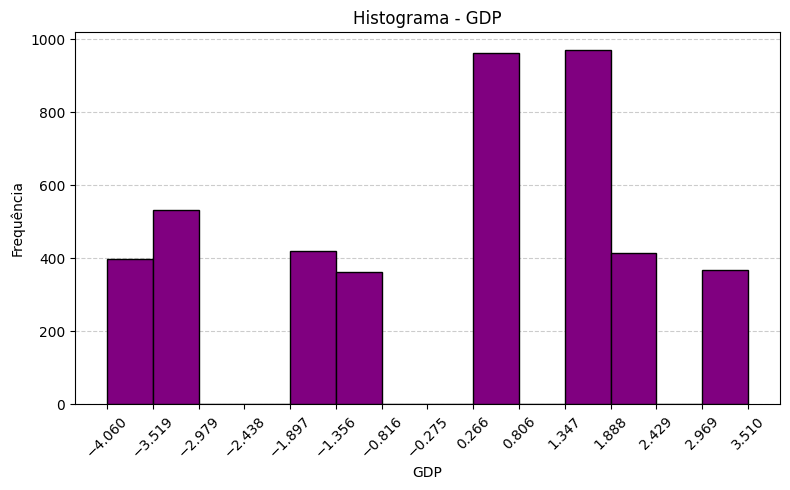


Distribuição de frequências - GDP
------------------------------------------------------------
Número de classes (k): 14
Amplitude total: 7.5700
Largura de classe (h): 0.5407
------------------------------------------------------------
Classe 01: [-4.06, -3.52] --> 397
Classe 02: [-3.52, -2.98] --> 533
Classe 03: [-2.98, -2.44] --> 0
Classe 04: [-2.44, -1.90] --> 0
Classe 05: [-1.90, -1.36] --> 419
Classe 06: [-1.36, -0.82] --> 362
Classe 07: [-0.82, -0.27] --> 0
Classe 08: [-0.27, 0.27] --> 0
Classe 09: [0.27, 0.81] --> 961
Classe 10: [0.81, 1.35] --> 0
Classe 11: [1.35, 1.89] --> 970
Classe 12: [1.89, 2.43] --> 414
Classe 13: [2.43, 2.97] --> 0
Classe 14: [2.97, 3.51] --> 368


In [52]:

# Chamada da função para plotagem de todos os 18 gráficos e informações para análise
distribuicoes_frequencias()


<h3>Referências</h3>

<p style="text-align: justify; margin-bottom: 12px;">
CASTRO, Leandro Nunes de; FERRARI, Daniel Gomes. <b>Introdução à mineração de dados: conceitos básicos, algoritmos e aplicações.</b> São Paulo: Saraiva, 2016.
</p>

<p style="text-align: justify; margin-bottom: 12px;">
UCI MACHINE LEARNING REPOSITORY. <b>Predict Students Dropout and Academic Success</b>. Disponível em: <a href="https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success" target="_blank">https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success</a>. Acesso em: 21 mar. 2026.
</p>
